# Event Weights

## Process the Data

- **Purpose:** Calculate concurrency-adjusted return attribution and normalized event weights.
- **Settings:** Floor zero return-attribution weights at the partition's smallest positive weight, then normalize sample weights to `mean=1`.
- **Data:** Labeled events with inline partitions produce the persisted event-weight columns.
- **Decision:** Compute development and holdout weights independently so neither partition influences the other.

In [1]:
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parents[1]

from src.preprocessing.event_weights import (
    WEIGHT_COLUMNS,
    build_partitioned_event_weights,
)

period = "2025-01-01_2025-12-31"
event_dir = PROJECT_ROOT / "data/research_data/events"
labeled_path = event_dir / f"aapl_labeled_events_{period}.parquet"
dollar_path = PROJECT_ROOT / f"data/research_data/market/features/aapl_dollar_bar_{period}.parquet"
weighted_path = event_dir / f"aapl_weighted_events_{period}.parquet"

events = pd.read_parquet(labeled_path).sort_values("event_start", ignore_index=True)
dollar_bars = pd.read_parquet(dollar_path).sort_values("end").drop_duplicates("end", keep="last")
events["event_start"] = pd.to_datetime(events["event_start"], utc=True)
events["event_end"] = pd.to_datetime(events["event_end"], utc=True)
close = dollar_bars.set_index("end")["close"].astype(float)


In [2]:
weighted_events = build_partitioned_event_weights(
    events,
    close,
)
weight_columns = WEIGHT_COLUMNS

weighted_events.to_parquet(weighted_path, index=False)
print(weighted_path)


/Users/kwonjunhyuk9/Documents/financial-machine-learning/data/research_data/events/aapl_weighted_events_2025-01-01_2025-12-31.parquet


## Take a Quick Look at the Data Structure

- **Purpose:** Inspect development label balance and the two event-weight distributions.
- **Settings:** No analytical parameters; read-only inspection.
- **Data:** Inspect only the development rows of the weighted-event artifact.
- **Decision:** Exclude holdout diagnostics and leave the artifact unchanged.

In [3]:
development_data = weighted_events.loc[
    weighted_events["partition"].eq("development")
]
development_data.head()

,event_start,symbol,event_end,vertical_barrier,target_return,raw_return,direction_label,partition,holdout_boundary,mean_sentiment_score,...,True Range,Average True Range,Keltner Channel Upper,Keltner Channel Middle,Keltner Channel Lower,Donchian Channel Upper,Donchian Channel Middle,Donchian Channel Lower,return_attribution_weight,sample_weight
0,2025-01-13 14:30:01.329809+00:00,AAPL,2025-01-13 14:34:17.401727+00:00,2025-01-16 18:19:25.547320+00:00,0.006302,-0.006778,-1,development,2025-10-16 17:14:45.827270+00:00,0.796031,...,9.60,0.8168,242.9775,241.3440,239.7104,242.800,237.9350,233.070,0.046828,5.877252
1,2025-01-16 14:30:01.488226+00:00,AAPL,2025-01-16 14:34:43.996829+00:00,2025-01-21 17:48:33.046371+00:00,0.004690,-0.004820,-1,development,2025-10-16 17:14:45.827270+00:00,0.168639,...,0.42,0.1261,237.9677,237.7155,237.4634,237.840,237.6300,237.420,0.005589,0.701415
2,2025-01-17 14:30:01.792073+00:00,AAPL,2025-01-17 14:39:01.069235+00:00,2025-01-22 20:42:17.531895+00:00,0.006821,-0.007032,-1,development,2025-10-16 17:14:45.827270+00:00,-0.898147,...,3.92,0.3121,229.3303,228.7060,228.0818,232.115,230.1125,228.110,0.008596,1.078822
3,2025-01-17 17:20:53.298606+00:00,AAPL,2025-01-21 14:30:00.854179+00:00,2025-01-23 16:19:31.331783+00:00,0.005790,-0.025297,-1,development,2025-10-16 17:14:45.827270+00:00,0.013412,...,0.17,0.2114,230.2595,229.8367,229.4138,230.110,229.8025,229.495,0.011908,1.494546
4,2025-01-21 14:30:00.854179+00:00,AAPL,2025-01-21 14:34:53.478136+00:00,2025-01-23 19:56:48.170064+00:00,0.005329,-0.007594,-1,development,2025-10-16 17:14:45.827270+00:00,-0.297837,...,6.15,0.5650,230.1386,229.0086,227.8786,230.010,226.9350,223.860,0.020989,2.634281


In [4]:
development_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 64 columns):
 #   Column                                    Non-Null Count  Dtype              
---  ------                                    --------------  -----              
 0   event_start                               157 non-null    datetime64[us, UTC]
 1   symbol                                    157 non-null    str                
 2   event_end                                 157 non-null    datetime64[us, UTC]
 3   vertical_barrier                          157 non-null    datetime64[us, UTC]
 4   target_return                             157 non-null    float64            
 5   raw_return                                157 non-null    float64            
 6   direction_label                           157 non-null    int8               
 7   partition                                 157 non-null    str                
 8   holdout_boundary                          157 non-null    datetime64[us

In [5]:
development_data["direction_label"].value_counts()

direction_label
 1    86
-1    71
Name: count, dtype: int64

In [6]:
development_data[weight_columns].describe()

,return_attribution_weight,sample_weight
count,157.000000,157.000000
mean,0.007968,1.000000
std,0.009515,1.194137
min,0.000018,0.002285
25%,0.002503,0.314119
50%,0.005396,0.677286
75%,0.008691,1.090818
max,0.056702,7.116486


array([[<Axes: title={'center': 'return_attribution_weight'}>,
        <Axes: title={'center': 'sample_weight'}>]], dtype=object)

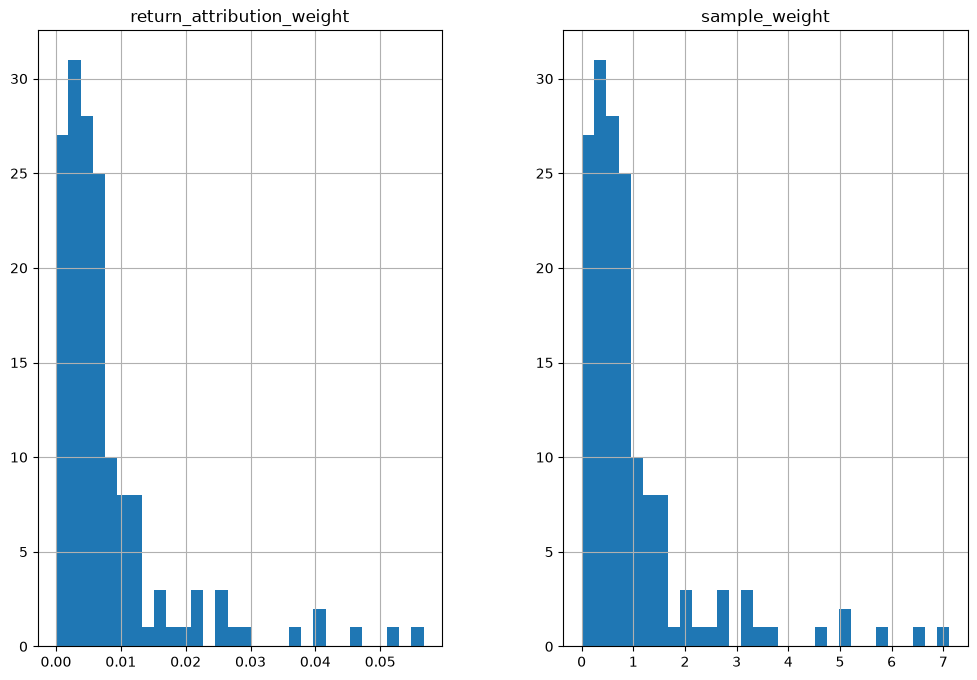

In [7]:
development_data[weight_columns].hist(figsize=(12, 8), bins=30)